# Permeator Probe plotting and post-processing for FESTIM simulation results. 

## Steady State Analysis 

Compare inlet, outlet, and probe diffusion fluxes. 

In [2]:
# PROBE IN

import numpy as np


permeation_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = -inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 0.6095619056840437% of inlet flux.
Advective flux at outlet is 100.20970308809221% of inlet flux.


In [ ]:
# PROBE OUT

import numpy as np


permeation_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = -inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 0.09933634204285591% of inlet flux.
Advective flux at outlet is 100.43864158030019% of inlet flux.


Calculate the pressure drop from inlet to outlet, based off of paraview-extracted data from OpenFOAM.

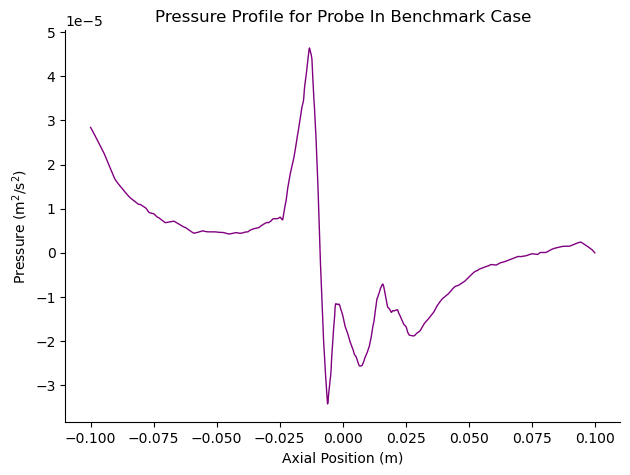

Pressure drop between inlet and outlet is 0.27739903580971387 Pa.
Absolute pressure drop between minima and maxima is 0.791123535556598 Pa.


In [4]:
# PROBE IN

import matplotlib.pyplot as plt
import numpy as np 

pressure_file = np.genfromtxt(
    "fixedconcentrationBC/festim_results_probe_in_benchmark/pressure.csv", delimiter=",", names=True
)
pressure = pressure_file["p"]
axial_position = pressure_file["Points1"]

plt.figure()
plt.plot(axial_position, pressure, color="purple", linewidth=1)
plt.xlabel("Axial Position (m)")
plt.ylabel(r"Pressure (m$^2$/s$^2$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Pressure Profile for Probe In Benchmark Case")
plt.show()

breeder_temperature = 603.15  # K from Utili 2023
LiPb_density = (
    10520.35 - 1.19051 * breeder_temperature
)  # kg/m3 ; equation from Martelli 2019

pressure_drop = (pressure[0]-pressure[-2]) * LiPb_density# convert m2/s2 to Pa 

print(f"Pressure drop between inlet and outlet is {pressure_drop} Pa.")

absolute_pressure_drop = (np.max(pressure) - np.min(pressure)) * LiPb_density 
print(f"Absolute pressure drop between minima and maxima is {absolute_pressure_drop} Pa.")



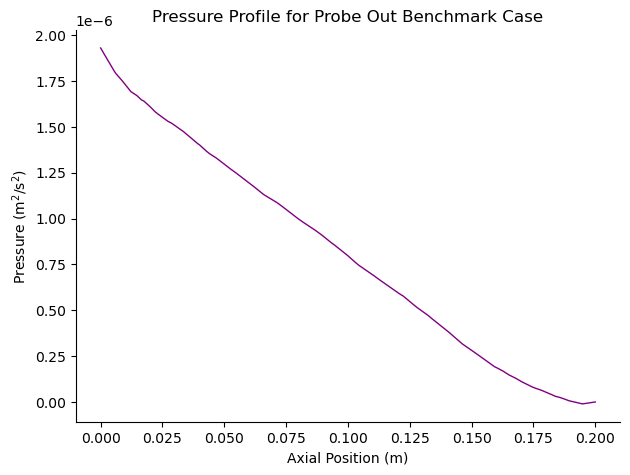

Pressure drop between inlet and outlet is 0.018922039163708878 Pa.
Absolute pressure drop between minima and maxima is 0.019022194297611594 Pa.


In [5]:
# PROBE OUT

import matplotlib.pyplot as plt
import numpy as np

pressure_file = np.genfromtxt(
    "OpenFOAM/benchmark_cases_LiPb/probe_out_kOmegaSST/pressure.csv", delimiter=",", names=True
)
pressure = pressure_file["p"]
axial_position = pressure_file["Points1"]

plt.figure()
plt.plot(axial_position, pressure, color="purple", linewidth=1)
plt.xlabel("Axial Position (m)")
plt.ylabel(r"Pressure (m$^2$/s$^2$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Pressure Profile for Probe Out Benchmark Case")
plt.show()

breeder_temperature = 603.15  # K from Utili 2023
LiPb_density = (
    10520.35 - 1.19051 * breeder_temperature
)  # kg/m3 ; equation from Martelli 2019

pressure_drop = (pressure[0]-pressure[-2]) * LiPb_density# convert m2/s2 to Pa 

print(f"Pressure drop between inlet and outlet is {pressure_drop} Pa.")

absolute_pressure_drop = (np.max(pressure) - np.min(pressure)) * LiPb_density 
print(f"Absolute pressure drop between minima and maxima is {absolute_pressure_drop} Pa.")

## OpenFOAM Abacus Post Processing

Generate abacus for various flow rates and impact on permeation flux.

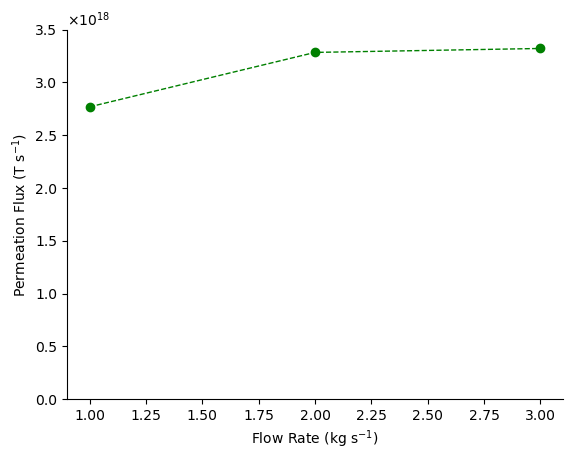

In [275]:
# PROBE IN
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

class OOMFormatter(ScalarFormatter):
    def __init__(self, order_of_m, fmt="%1.1f", useMathText=True):
        self.order_of_m = order_of_m
        self.fmt = fmt
        super().__init__(useMathText=useMathText)

    def _set_format(self):
        self.format = self.fmt

y_formatter = OOMFormatter(18, fmt="%1.1f")

flow_rates = [1,2,3] # kg/s 

# first flow rate is benchmark case 
permeation_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes = [permeation_1kgs["H_flux_surface_7"]]
outlet_fluxes = [outlet_1kgs["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_in/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["T_flux_surface_7"])
    outlet_fluxes.append(outlet["T_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Flux (T s$^{-1}$)")
plt.ylim(ymin=0,ymax=3.5e18)
# plt.yscale('log')
ax = plt.gca()
ax.yaxis.set_major_formatter(y_formatter)
ax.ticklabel_format(axis='y', style='sci', useMathText=True)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe In: Inlet Flow Rate vs. Permeation Flux")
plt.savefig("openfoam-abacus-probe-in.pdf")
plt.show()


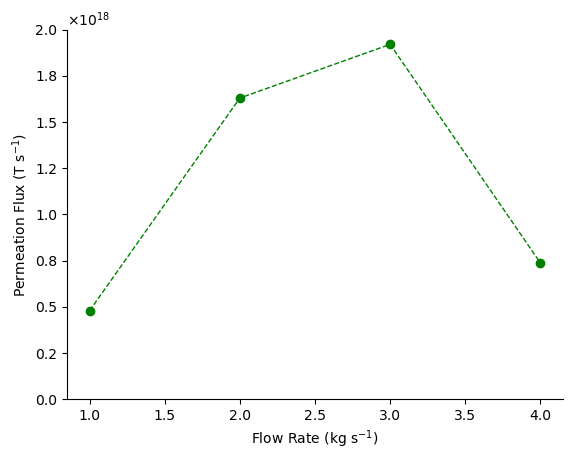

In [254]:
# PROBE OUT
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

class OOMFormatter(ScalarFormatter):
    def __init__(self, order_of_m, fmt="%1.1f", useMathText=True):
        self.order_of_m = order_of_m
        self.fmt = fmt
        super().__init__(useMathText=useMathText)

    def _set_format(self):
        self.format = self.fmt

y_formatter = OOMFormatter(18, fmt="%1.1f")

flow_rates = [1,2,3,4] # kg/s 

# first flow rate is benchmark case 
permeation_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes = [permeation_1kgs["H_flux_surface_7"]]
outlet_fluxes = [outlet_1kgs["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_out/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Flux (T s$^{-1}$)")
plt.ylim(ymin=0,ymax=2e18)

# plt.yscale('log')
ax = plt.gca()
ax.yaxis.set_major_formatter(y_formatter)
ax.ticklabel_format(axis='y', style='sci', useMathText=True)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe Out: Inlet Flow Rate vs. Permeation Flux")
plt.savefig("openfoam-abacus-probe-out.pdf")
plt.show()


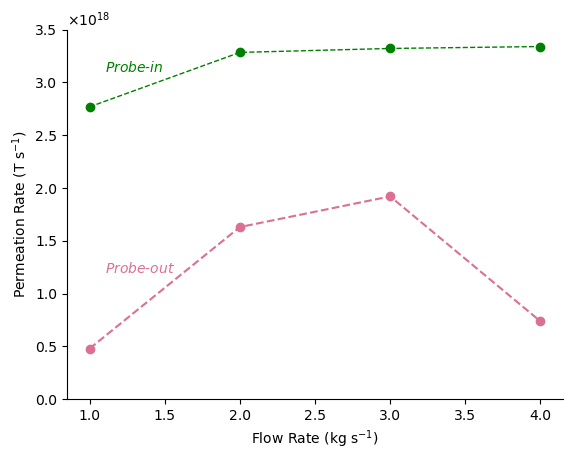

In [5]:
# ON SAME GRAPH 

# PROBE IN
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker
import numpy as np 
import matplotlib.pyplot as plt

class OOMFormatter(ScalarFormatter):
    def __init__(self, order_of_m, fmt="%1.1f", useMathText=True):
        self.order_of_m = order_of_m
        self.fmt = fmt
        super().__init__(useMathText=useMathText)

    def _set_format(self):
        self.format = self.fmt

y_formatter = OOMFormatter(18, fmt="%1.1f")

flow_rates = [1,2,3,4] # kg/s 

# probe in 
# first flow rate is benchmark case 
permeation_1kgs_probe_in = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs_probe_in = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes_probe_in = [permeation_1kgs_probe_in["H_flux_surface_7"]]
outlet_fluxes_probe_in = [outlet_1kgs_probe_in["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_in/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes_probe_in.append(permeation["T_flux_surface_7"])
    outlet_fluxes_probe_in.append(outlet["T_advection_flux_surface_6"])


# probe out 
# first flow rate is benchmark case 
permeation_1kgs_probe_out = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs_probe_out = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes_probe_out = [permeation_1kgs_probe_out["H_flux_surface_7"]]
outlet_fluxes_probe_out = [outlet_1kgs_probe_out["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_out/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes_probe_out.append(permeation["H_flux_surface_7"])
    outlet_fluxes_probe_out.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes_probe_in, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes_probe_in, color="green", linestyle='--', linewidth=1)
plt.annotate(r"$\it{Probe}$-$\it{in}$", xy=(1.1,3.1e18), color="green")

plt.scatter(flow_rates, permeation_fluxes_probe_out, color="palevioletred", linewidth=1)
plt.plot(flow_rates, permeation_fluxes_probe_out, color="palevioletred", linestyle='--')
plt.annotate(r"$\it{Probe}$-$\it{out}$", xy=(1.1,1.2e18), color="palevioletred")

plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Rate (T s$^{-1}$)")
plt.ylim(ymin=0,ymax=3.5e18)

# plt.yscale('log')
ax = plt.gca()
ax.yaxis.set_major_formatter(y_formatter)
ax.ticklabel_format(axis='y', style='sci', useMathText=True)
ax.tick_params(labeltop=False, labelbottom=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig("openfoam-abacus-both.pdf")
plt.show()



## FESTIM Abacus Post Processing

Generate abacus for various inlet concentrations and impact on permeation flux. 

<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_92275/4140230309.py:61: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(inlet_concentrations[6:], y_fit(inlet_concentrations[6:]), color='darkorange',linestyle='--', linewidth=1, label = (("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_92275/4140230309.py:65: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(conver

Diffusion-Limited Best Fit Line (y=1.91e+17*x^1.12) with R^2 value 0.9990168673486635.
Surface-Limited Best Fit Line (y=5.06e+18*x^1.74) with R^2 value 0.9979429508348776.


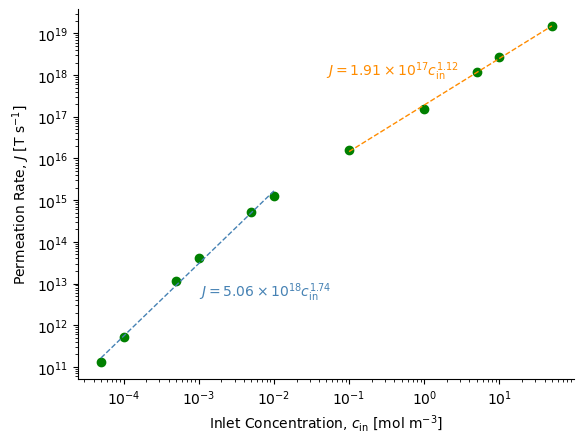

In [1]:
# PROBE IN -- paper
from sklearn.metrics import r2_score
import scipy
import numpy as np
import matplotlib.pyplot as plt

inlet_concentrations = [
    5e-5,
    1e-4,
    5e-4,
    1e-3,
    5e-3,
    1e-2,
    1e-1,
    1,
    5,
    1e1,
    5e1,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", linewidth=1, label="Simulated Data")

def convert_to_sci_notation(x):
    """
    Converts number to scientific notation for use in legend 
    on permeation flux vs. inlet concentration plots. 
    """
    s = '{x:0.{ndp:d}e}'.format(x=x, ndp=2)
    m, e = s.split('e')
    return r'{m:s}\times 10^{{{e:d}}}'.format(m=m, e=int(e))

# best fit line diffusion-limited
logx_diffusion = np.log(inlet_concentrations[6:])
logy_diffusion = np.log(permeation_fluxes[6:])

coefficients = np.polyfit(logx_diffusion, logy_diffusion, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx_diffusion, logy_diffusion)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations[6:], y_fit(inlet_concentrations[6:]), color='darkorange',linestyle='--', linewidth=1, label = (("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
print(f'Diffusion-Limited Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

# annotation
plt.annotate(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m)), xy=(50e-3,10e17), color='darkorange') # diffusion-limited 
# plt.annotate("Almost DLR", xy=(50e-4,10e16), color='darkorange', fontsize=15) # diffusion-limited 


# best fit line surface-limited
logx_surface = np.log(inlet_concentrations[:6])
logy_surface = np.log(permeation_fluxes[:6])

coefficients = np.polyfit(logx_surface, logy_surface, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx_surface, logy_surface)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations[:6], y_fit(inlet_concentrations[:6]), color='steelblue',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
print(f'Surface-Limited Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

# annotation
plt.annotate(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m)),xy=(10e-4,50e11), color='steelblue') # surface-limited 
# plt.annotate("Almost SLR", xy=(20e-5,50e10), color='steelblue', fontsize=15) # surface-limited 

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration, $c_{\mathrm{in}}$ [mol m$^{-3}$]")
plt.ylabel(r"Permeation Rate, $\it{J}$ [T s$^{-1}$]")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe In: Inlet Concentration vs. Permeation Flux")
plt.savefig("festim-abacus-probe-in.pdf")
plt.show()


<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\p'
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_5538/3053549204.py:61: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(inlet_concentrations[6:], y_fit(inlet_concentrations[6:]), color='darkorange',linestyle='--', linewidth=1, label = (("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_5538/3053549204.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.annotate(("$J \propto c_{{\mathrm{{in}}}}^{{{}}}$").format("{:.2f}"

Diffusion-Limited Best Fit Line (y=1.91e+17*x^1.12) with R^2 value 0.9990168673486635.
Surface-Limited Best Fit Line (y=5.06e+18*x^1.74) with R^2 value 0.9979429508348776.


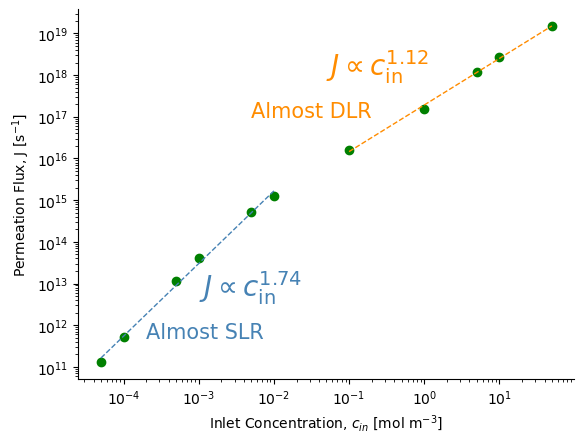

In [ ]:
# PROBE IN -- presentation
from sklearn.metrics import r2_score
import scipy
import numpy as np
import matplotlib.pyplot as plt

inlet_concentrations = [
    5e-5,
    1e-4,
    5e-4,
    1e-3,
    5e-3,
    1e-2,
    1e-1,
    1,
    5,
    1e1,
    5e1,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", linewidth=1, label="Simulated Data")

def convert_to_sci_notation(x):
    """
    Converts number to scientific notation for use in legend 
    on permeation flux vs. inlet concentration plots. 
    """
    s = '{x:0.{ndp:d}e}'.format(x=x, ndp=2)
    m, e = s.split('e')
    return r'{m:s}\times 10^{{{e:d}}}'.format(m=m, e=int(e))

# best fit line diffusion-limited
logx_diffusion = np.log(inlet_concentrations[6:])
logy_diffusion = np.log(permeation_fluxes[6:])

coefficients = np.polyfit(logx_diffusion, logy_diffusion, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx_diffusion, logy_diffusion)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations[6:], y_fit(inlet_concentrations[6:]), color='darkorange',linestyle='--', linewidth=1, label = (("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
print(f'Diffusion-Limited Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

# annotation
plt.annotate(("$J \propto c_{{\mathrm{{in}}}}^{{{}}}$").format("{:.2f}".format(m)), xy=(50e-3,10e17), color='darkorange', fontsize=20) # diffusion-limited 
plt.annotate("Almost DLR", xy=(50e-4,10e16), color='darkorange', fontsize=15) # diffusion-limited 


# best fit line surface-limited
logx_surface = np.log(inlet_concentrations[:6])
logy_surface = np.log(permeation_fluxes[:6])

coefficients = np.polyfit(logx_surface, logy_surface, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx_surface, logy_surface)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations[:6], y_fit(inlet_concentrations[:6]), color='steelblue',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
print(f'Surface-Limited Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

# annotation
plt.annotate(("$J \propto c_{{\mathrm{{in}}}}^{{{}}}$").format("{:.2f}".format(m)),xy=(10e-4,50e11), color='steelblue', fontsize=20) # surface-limited 
plt.annotate("Almost SLR", xy=(20e-5,50e10), color='steelblue', fontsize=15) # surface-limited 

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration, $c_{in}$ [mol m$^{-3}$]")
plt.ylabel(r"Permeation Flux, J [s$^{-1}$]")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe In: Inlet Concentration vs. Permeation Flux")
plt.savefig("festim-abacus-probe-in.pdf")
plt.show()


<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_92275/4286143700.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='darkorange',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_92275/4286143700.py:42: SyntaxWarning: invalid escape sequence '\m'
  plt.annotate(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m)),xy=(2,30e16), color='darkorange') # surface-limited


Best Fit Line (y=2.59e+16*x^1.21) with R^2 value 0.9973788746041775.


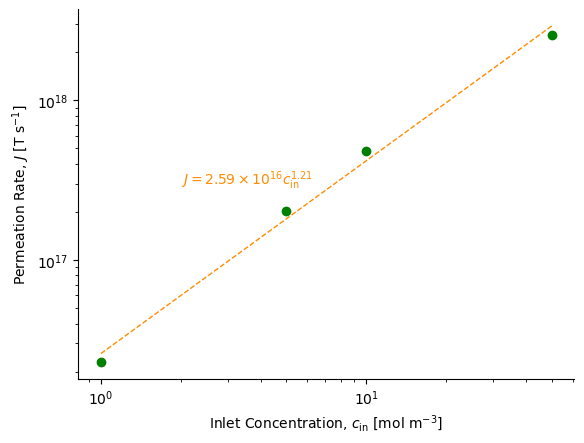

In [2]:
# PROBE OUT -- paper

inlet_concentrations = mol_m3_c_in = [
    1,
    5,
    1e01,
    5e01,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", label="Simulated Data")

# best fit line 
logx = np.log(inlet_concentrations)
logy = np.log(permeation_fluxes)

coefficients = np.polyfit(logx, logy, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx, logy)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='darkorange',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
plt.annotate(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m)),xy=(2,30e16), color='darkorange') # surface-limited 
# plt.annotate("Almost DLR",xy=(1,20e16), color='darkorange', fontsize=15) # surface-limited 

print(f'Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration, $c_{\mathrm{in}}$ [mol m$^{-3}$]")
plt.ylabel(r"Permeation Rate, $\it{J}$ [T s$^{-1}$]")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe Out: Inlet Concentration vs. Permeation Flux")
plt.savefig("festim-abacus-probe-out.pdf")
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_5538/3462881052.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='darkorange',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
/var/folders/r2/yk73fmys7h9gl6xty3rggb8r0000gn/T/ipykernel_5538/3462881052.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.annotate(("$J = \propto c_{{\mathrm{{in}}}}^{{{}}}$").format("{:.2f}".format(m)),xy=(2,30e16), color='darkorange', fontsize=20) # surface-limited


Best Fit Line (y=2.59e+16*x^1.21) with R^2 value 0.9973788746041775.


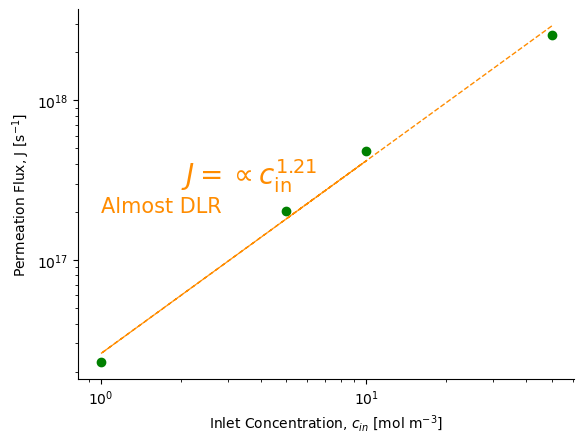

In [ ]:
# PROBE OUT -- presentation

inlet_concentrations = mol_m3_c_in = [
    5,
    1e01,
    1,
    5e01,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", label="Simulated Data")

# best fit line 
logx = np.log(inlet_concentrations)
logy = np.log(permeation_fluxes)

coefficients = np.polyfit(logx, logy, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m

slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(logx, logy)
linear_fit = lambda x: slope*x + intercept # produces the same line as y_fit plotted on a log-log scale 

plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='darkorange',linestyle='--', linewidth=1, label=(("$J = {{{}}}c_{{\mathrm{{in}}}}^{{{}}}$").format(convert_to_sci_notation(np.exp(c)), "{:.2f}".format(m))+ r", R$^2$ ="+f" {r_value:.3f}"))
plt.annotate(("$J = \propto c_{{\mathrm{{in}}}}^{{{}}}$").format("{:.2f}".format(m)),xy=(2,30e16), color='darkorange', fontsize=20) # surface-limited 
plt.annotate("Almost DLR",xy=(1,20e16), color='darkorange', fontsize=15) # surface-limited 


print(f'Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f}) with R^2 value {r_value}.')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration, $c_{in}$ [mol m$^{-3}$]")
plt.ylabel(r"Permeation Flux, J [s$^{-1}$]")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe Out: Inlet Concentration vs. Permeation Flux")
plt.savefig("festim-abacus-probe-out.pdf")
plt.show()

Compare impact of mode on permeation flux measurements. 

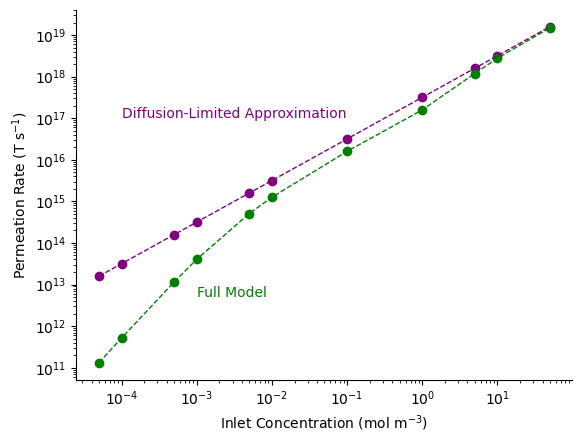

In [3]:
# PROBE IN - paper 

import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.metrics import r2_score
import scipy
import numpy as np
import matplotlib.pyplot as plt

inlet_concentrations = [
    5e-5,
    1e-4,
    5e-4,
    1e-3,
    5e-3,
    1e-2,
    1e-1,
    1,
    5,
    1e1,
    5e1,
]  # mol/m3

diffusion_limited_permeation_fluxes = []
surface_limited_permeation_fluxes = []

for conc in inlet_concentrations:
    approximation_file_path = f"fixedconcentrationBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    approximated_permeation = np.genfromtxt(
        approximation_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    diffusion_limited_permeation_fluxes.append(approximated_permeation["T_flux_surface_7"])

    full_model_file_path = f"surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    full_model_permeation = np.genfromtxt(
        full_model_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    surface_limited_permeation_fluxes.append(full_model_permeation["H_flux_surface_7"])

plt.figure()
plt.scatter(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, label="Diffusion-Limited Approximation")
plt.plot(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, linestyle='--')
plt.annotate("Diffusion-Limited Approximation", xy=(1e-4,1e17), color='purple')


plt.scatter(inlet_concentrations, surface_limited_permeation_fluxes, color="green", linewidth=1, label="Full Model")
plt.plot(inlet_concentrations, surface_limited_permeation_fluxes, color="green", linewidth=1, linestyle='--')
plt.annotate("Full Model", xy=(1e-3,5e12), color='green')


plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Rate (T s$^{-1}$)")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title(r"$\it{probe-in}$ Tritrium Transport Regime Comparison")
plt.savefig("mode-compare-probe-in.pdf")
plt.show()

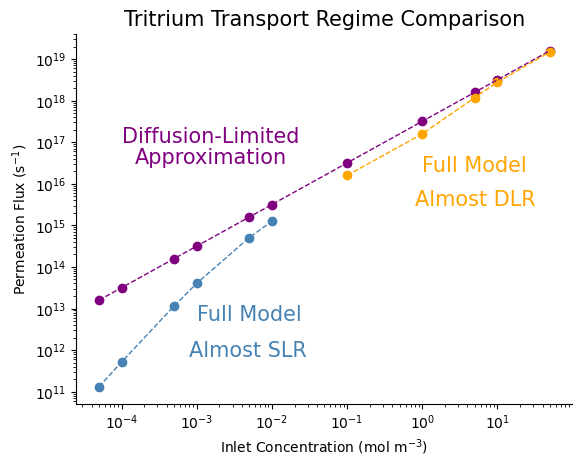

In [ ]:
# PROBE IN - presentation 

import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.metrics import r2_score
import scipy
import numpy as np
import matplotlib.pyplot as plt

inlet_concentrations = [
    5e-5,
    1e-4,
    5e-4,
    1e-3,
    5e-3,
    1e-2,
    1e-1,
    1,
    5,
    1e1,
    5e1,
]  # mol/m3

diffusion_limited_permeation_fluxes = []
surface_limited_permeation_fluxes = []

for conc in inlet_concentrations:
    approximation_file_path = f"fixedconcentrationBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    approximated_permeation = np.genfromtxt(
        approximation_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    diffusion_limited_permeation_fluxes.append(approximated_permeation["T_flux_surface_7"])

    full_model_file_path = f"surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    full_model_permeation = np.genfromtxt(
        full_model_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    surface_limited_permeation_fluxes.append(full_model_permeation["H_flux_surface_7"])

plt.figure()
plt.scatter(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, label="Diffusion-Limited Approximation")
plt.plot(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, linestyle='--')
plt.annotate("Diffusion-Limited", xy=(1e-4,1e17), color='purple', fontsize=15)
plt.annotate("Approximation", xy=(1.5e-4,3e16), color='purple', fontsize=15)


plt.scatter(inlet_concentrations[:6], surface_limited_permeation_fluxes[:6], color="steelblue", linewidth=1, label="Full Model")
plt.plot(inlet_concentrations[:6], surface_limited_permeation_fluxes[:6], color="steelblue", linewidth=1, linestyle='--')
plt.annotate("Full Model", xy=(1e-3,5e12), color='steelblue', fontsize=15)
plt.annotate("Almost SLR", xy=(8e-4,7e11), color='steelblue', fontsize=15)

plt.scatter(inlet_concentrations[6:], surface_limited_permeation_fluxes[6:], color="orange", linewidth=1, label="Full Model")
plt.plot(inlet_concentrations[6:], surface_limited_permeation_fluxes[6:], color="orange", linewidth=1, linestyle='--')
plt.annotate("Full Model", xy=(1e0,2e16), color='orange', fontsize=15)
plt.annotate("Almost DLR", xy=(8e-1,3e15), color='orange', fontsize=15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Tritrium Transport Regime Comparison", fontsize=15)
plt.savefig("mode-compare-probe-in.pdf")
plt.show()

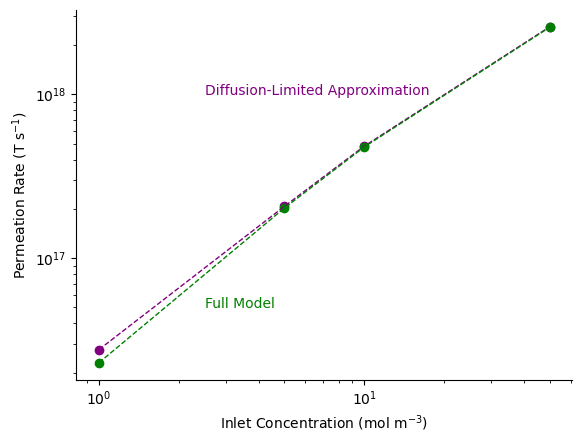

In [4]:
# PROBE OUT 

import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.metrics import r2_score
import scipy
import numpy as np
import matplotlib.pyplot as plt

inlet_concentrations = [1,5,1e01,5e01] # mol/m3
diffusion_limited_permeation_fluxes = []
surface_limited_permeation_fluxes = []

for conc in inlet_concentrations:
    approximated_file_path = f"fixedconcentrationBC/festim_abacus_probe_out/festim_results_cin_{conc}_mol_m3"
    approximated_permeation = np.genfromtxt(
        approximated_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    diffusion_limited_permeation_fluxes.append(approximated_permeation["H_flux_surface_7"])

    full_model_file_path = f"surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_{conc}_mol_m3"
    full_model_permeation = np.genfromtxt(
        full_model_file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    surface_limited_permeation_fluxes.append(full_model_permeation["H_flux_surface_7"])

plt.figure()
plt.scatter(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, label="Diffusion-Limited Approximation")
plt.plot(inlet_concentrations, diffusion_limited_permeation_fluxes, color="purple", linewidth=1, linestyle='--')
plt.annotate("Diffusion-Limited Approximation", xy=(2.5,1e18), color='purple')

plt.scatter(inlet_concentrations, surface_limited_permeation_fluxes, color="green", linewidth=1, label="Full Model")
plt.plot(inlet_concentrations, surface_limited_permeation_fluxes, color="green", linewidth=1, linestyle='--')
plt.annotate("Full Model", xy=(2.5,5e16), color='green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Rate (T s$^{-1}$)")
# plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.title("Probe out: Tritrium Transport Regime Comparison")
plt.savefig("mode-compare-probe-out.pdf")
plt.show()

Detectability Assessment

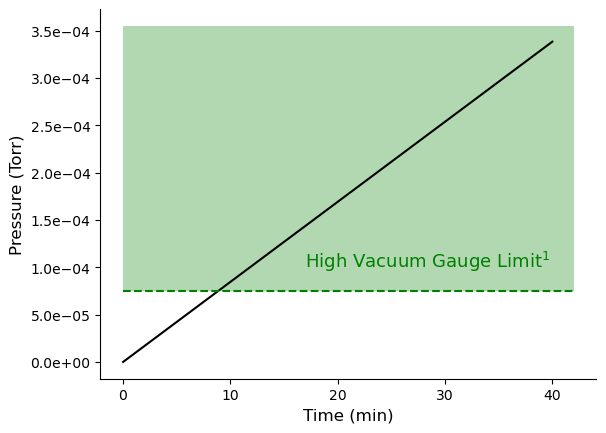

In [234]:
# pressure vs time graph to show detectability limits 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches

class OOMFormatter(ScalarFormatter):
    def __init__(self, order_of_m, fmt="%1.1e", useMathText=True):
        self.order_of_m = order_of_m
        self.fmt = fmt
        super().__init__(useMathText=useMathText)

    def _set_format(self):
        self.format = self.fmt

y_formatter = OOMFormatter(1, fmt="%1.1e")

lowest_dP_dt = 1.41e-7 # Torr/s
higher_dP_dt = 0.013 # Torr/s


time_min = 1
time_max = 86400/36 #3*60 # over one hour

times = np.linspace(time_min,time_max,100) 

pressures = lowest_dP_dt * times
# pressures = higher_dP_dt * times

plt.figure()
plt.plot(times/60, pressures, color='black')
plt.hlines(7.5e-5, xmin=0, xmax=42, linestyles='--', color='green')
# plt.hlines(0.1, xmin=0, xmax=3, linestyles='--', color='blue')

plt.annotate(r"High Vacuum Gauge Limit$^1$", xy=(17,1e-4), color='green', fontsize = 13)
# plt.annotate(r"Conventional Manometer Limit$^2$", xy=(1,0.3), color='blue', fontsize = 13)

plt.xlabel(r"Time (min)", fontsize=12)
plt.ylabel(r"Pressure (Torr)", fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_formatter(y_formatter)
ax.ticklabel_format(axis='y', style='sci', useMathText=True)

rect = patches.Rectangle((0, 7.5e-5), 42, 2.8e-4, facecolor='green', alpha=0.3)
ax.add_patch(rect)

# rect = patches.Rectangle((0, 0.1), 3, 2.3, facecolor='blue', alpha=0.3)
# ax.add_patch(rect)

plt.savefig("detectability-limit-low.png")
plt.show()
